In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [3]:
# Load CSV
df = pd.read_csv('Concrete_Data.csv')
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
# Clean column names
df.columns = [col.strip().split('(')[0].strip().replace(' ', '_') for col in df.columns]
df.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


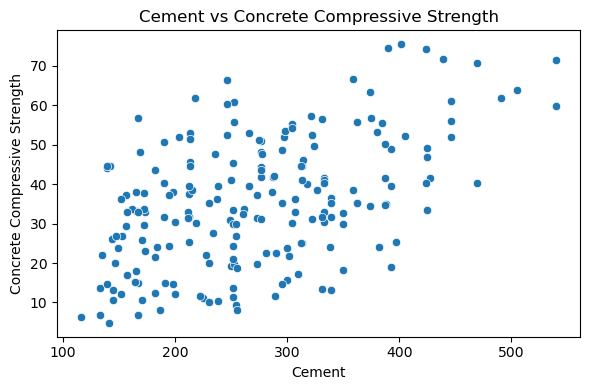

In [19]:
#Scatter of the target variable vs. one feature (e.g., 'Cement')
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_test['Cement'], y=y_test)
plt.xlabel("Cement")
plt.ylabel("Concrete Compressive Strength")
plt.title("Cement vs Concrete Compressive Strength")
plt.tight_layout()
plt.show()

In [7]:
# Features and target
X = df.drop('Concrete_compressive_strength', axis=1)
y = df['Concrete_compressive_strength']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model training
model = RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

In [9]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 3.738269765950071
Mean Squared Error: 29.90901641957394
Root Mean Squared Error: 5.4689136416270046
R² Score: 0.8839282175707699


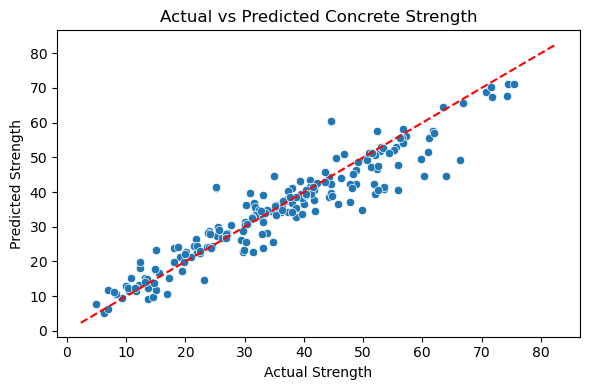

In [11]:
# Plot: Predicted vs Actual
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted Concrete Strength")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.tight_layout()
plt.show()

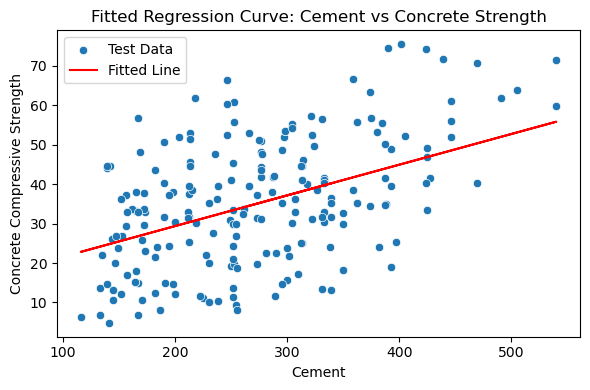

In [25]:
reg_model = LinearRegression()
reg_model.fit(X_train[['Cement']], y_train)

# Predictions for the test set
y_pred_reg = reg_model.predict(X_test[['Cement']])

# Scatter plot with the fitted line
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_test['Cement'], y=y_test, label='Test Data')
plt.plot(X_test['Cement'], y_pred_reg, color='red', label='Fitted Line')
plt.xlabel("Cement")
plt.ylabel("Concrete Compressive Strength")
plt.title("Fitted Regression Curve: Cement vs Concrete Strength")
plt.legend()
plt.tight_layout()
plt.show()

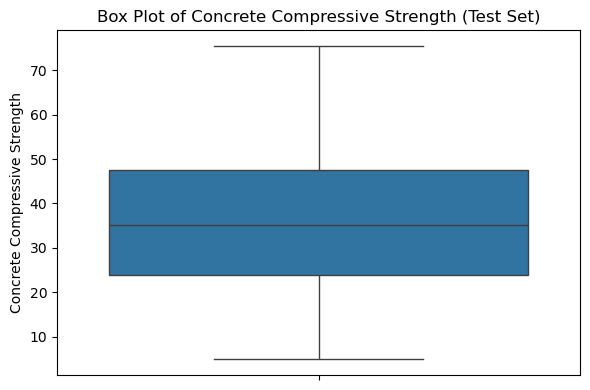

In [29]:
#Box Plot of Target Variable (Concrete_compressive_strength)
plt.figure(figsize=(6, 4))
sns.boxplot(y=y_test)
plt.title("Box Plot of Concrete Compressive Strength (Test Set)")
plt.ylabel("Concrete Compressive Strength")
plt.tight_layout()
plt.show()

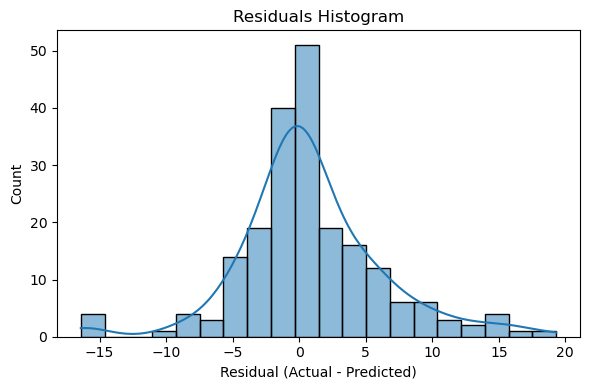

In [31]:
# Plot: Residuals
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=20)
plt.title("Residuals Histogram")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

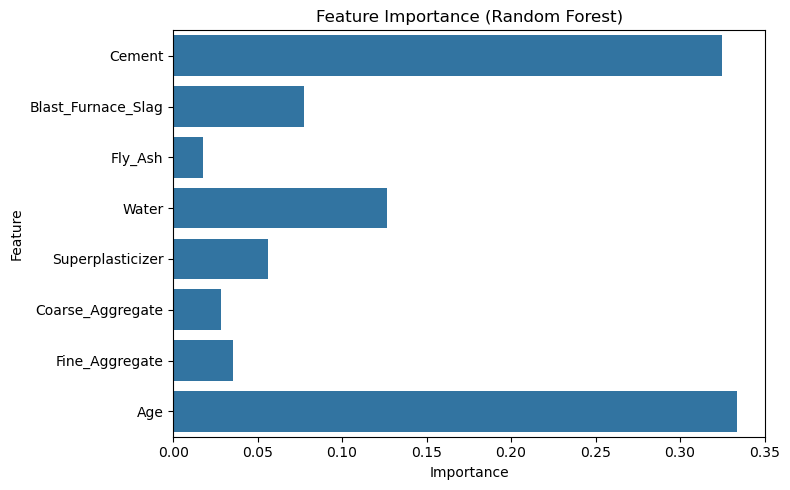

In [15]:
# Plot: Feature Importance
importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()